### La población de la especie Platanus x acerifolia (Plátano) presenta una estructura de edad poco diversa, indicativa de un "conjunto de edad única" (monocultivo de edad).

Esta falta de diversidad etaria se manifiesta estadísticamente como una variabilidad relativa del diámetro (DAP) significativamente menor en comparación con otras especies de alta frecuencia en el arbolado urbano (como Fraxinus pennsylvanica o Jacaranda mimosifolia).

El descubrimiento de un conjunto de edad única en la especie dominante de gran porte no es un dato trivial; representa uno de los mayores riesgos estratégicos para la gestión del arbolado urbano.

La implicancia directa es un riesgo de "senescencia masiva".

Una población de árboles plantada masivamente en el mismo período (principios/mediados del s. XX) envejecerá y entrará en senescencia de forma simultánea.

Esto genera dos problemas críticos para la gestión de la ciudad:

Riesgo de Servicio Ecosistémico: Dado que los Plátanos son los árboles de mayor porte (como se vio en la Hipótesis 6), su declive simultáneo provocaría una pérdida abrupta y masiva de los servicios ecosistémicos que proveen (sombra, captura de carbono, filtrado de aire), creando "islas de calor" donde antes había cobertura.

Riesgo Presupuestario ("Bomba de Tiempo"): El manejo de arbolado senescente (podas de alta complejidad, tratamiento de plagas, extracción y reemplazo) es la tarea más costosa. En lugar de un gasto de mantenimiento distribuido uniformemente en el tiempo, la ciudad enfrentará un pico de gasto extraordinario concentrado en un período de 10-20 años, cuando toda esta cohorte requiera intervención al mismo tiempo.

Conclusión Accionable: El análisis recomienda iniciar un plan de gestión proactiva de reemplazo y diversificación para mitigar este riesgo.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt



In [3]:
datos_limpios= pd.read_pickle('../data/datos_arbolado')

In [4]:
datos_limpios.head()

,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,1.0,NaN,Esmeralda,1000,11200,Tipuana tipu,5.5,2.0,Regular,1.0,88.0,34.0
1,-58.381532,-34.592319,1.0,NaN,Pellegrini Carlos,1300,13450,Otra,4.5,2.0,Regular,2.0,6.0,5.0
2,-58.379103,-34.591939,1.0,NaN,Arroyo,800,8480,Fraxinus pennsylvanica,4.0,2.0,Regular,1.0,7.0,6.0
5,-58.381043,-34.591584,1.0,NaN,Arroyo,900,9700,Fraxinus pennsylvanica,3.5,2.0,Regular,1.0,29.0,15.0
6,-58.380968,-34.591576,1.0,NaN,Arroyo,900,9620,Fraxinus pennsylvanica,4.5,2.0,Regular,1.0,21.0,12.0


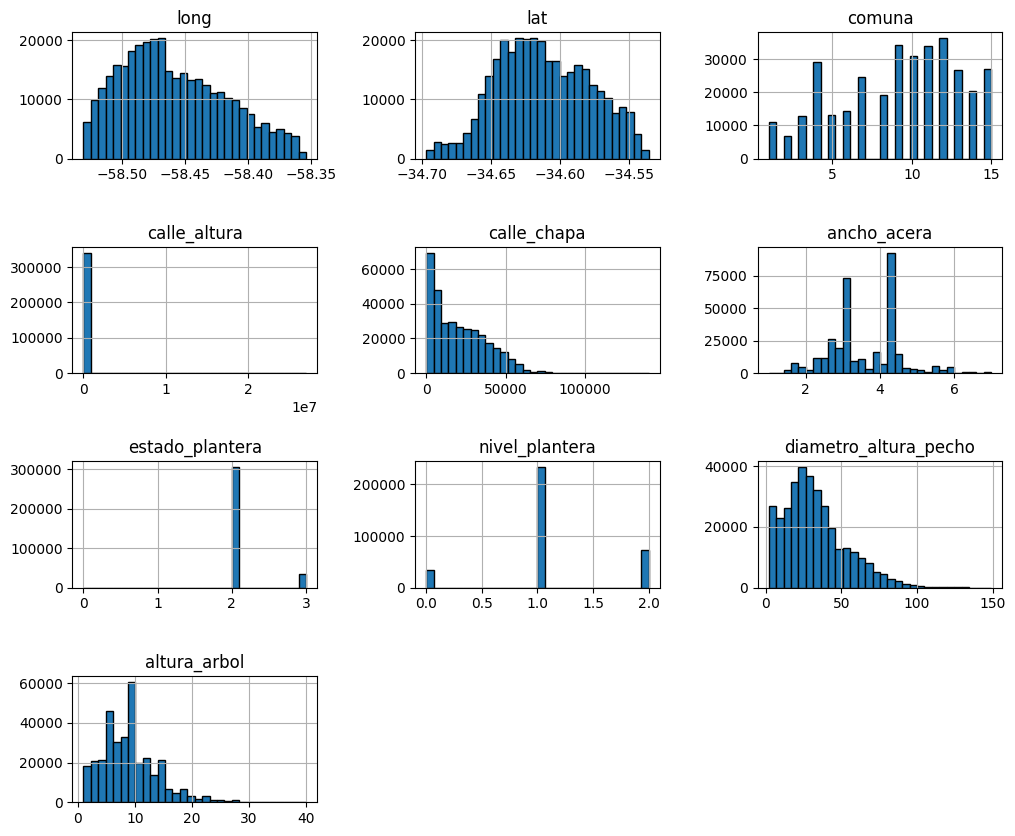

In [5]:
datos_limpios.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)

In [11]:
import numpy as np


stats_por_especie = datos_limpios.groupby('nombre_cientifico')['diametro_altura_pecho'].agg(
    ['mean', 'median', 'std', 'var', 'count']
)

stats_por_especie['CV_percent'] = (stats_por_especie['std'] / stats_por_especie['mean']) * 100

stats_por_especie = stats_por_especie.sort_values(by='count', ascending=False)
print("--- CV del DAP por Especie (ordenado de menor a mayor variabilidad) ---")
print(stats_por_especie.sort_values(by='CV_percent').head(10))

--- CV del DAP por Especie (ordenado de menor a mayor variabilidad) ---
                             mean  median        std         var   count  \
nombre_cientifico                                                          
Platanus x acerifolia   61.107167    62.0  19.734424  389.447474   30056   
Melia azedarach         55.176696    57.0  21.276744  452.699841   14075   
Fraxinus pennsylvanica  31.299051    30.0  14.316229  204.954419  128366   
Tipuana tipu            53.642875    57.0  24.614566  605.876861    8154   
Fraxinus excelsior      29.601069    28.0  13.773141  189.699418    8232   
Fraxinus americana      30.947717    30.0  14.826031  219.811203    9659   
Ligustrum lucidum       23.841692    22.0  11.954869  142.918886    8654   
Tilia x moltkei         26.144243    26.0  13.443164  180.718648   14843   
Ficus benjamina         34.603902    30.0  22.126728  489.592075   21477   
Jacaranda mimosifolia   23.508464    21.0  16.818912  282.875787   12819   

               

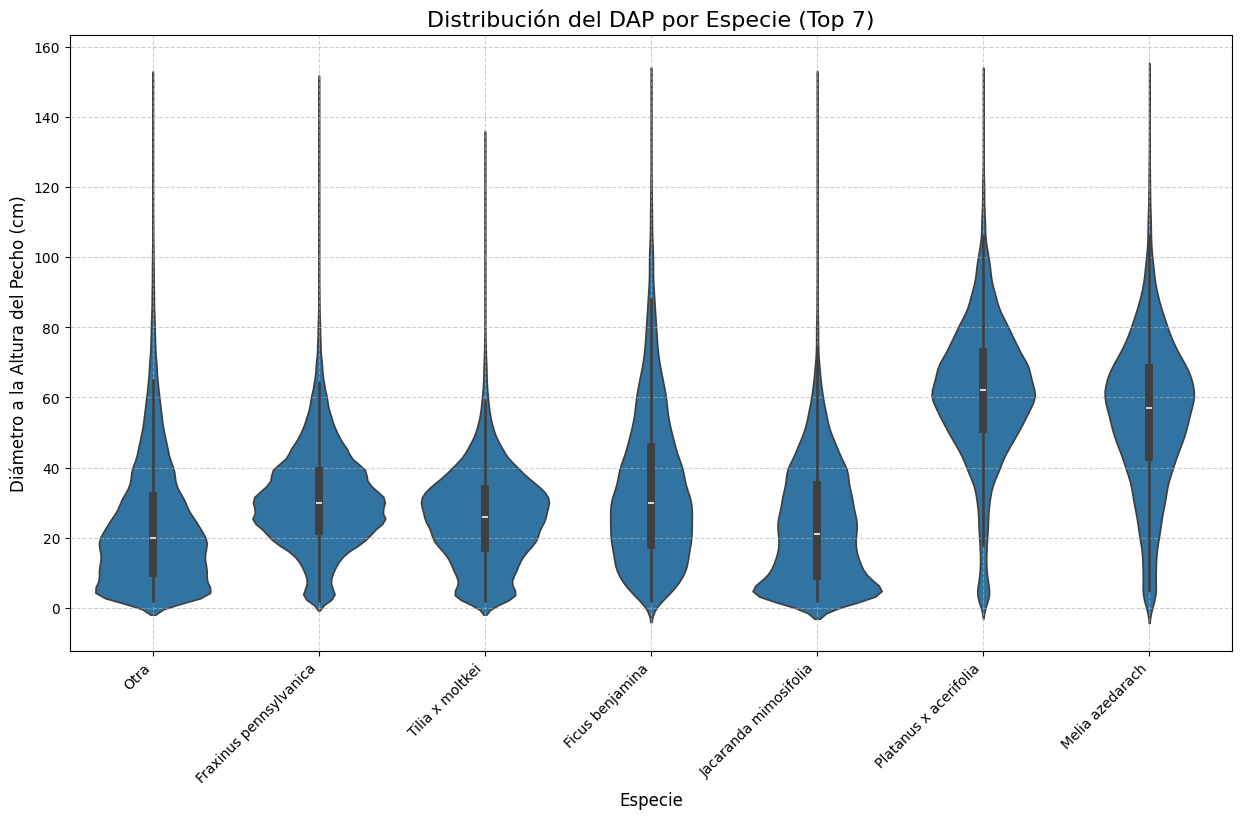

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Obtengo la lista de las 7 especies más comunes
top_species = datos_limpios['nombre_cientifico'].value_counts().nlargest(7).index

# Filtro el DataFrame para incluir solo esas especies
df_top_species = datos_limpios[
    datos_limpios['nombre_cientifico'].isin(top_species)
]

# Creo el Violin Plot
plt.figure(figsize=(15, 8))
sns.violinplot(
    data=df_top_species, 
    x='nombre_cientifico', 
    y='diametro_altura_pecho'
)
plt.title('Distribución del DAP por Especie (Top 7)', fontsize=16)
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()